In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, random, math
import numpy as np
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_curve, auc
BASE = "/content/drive/MyDrive/hack/hackathon"
OK_DIR = os.path.join(BASE, "Images Originales")
DF_DIR = os.path.join(BASE, "Objets A Detecter")

print("OK_DIR:", OK_DIR, "| exists:", os.path.exists(OK_DIR))
print("DF_DIR:", DF_DIR, "| exists:", os.path.exists(DF_DIR))

exts = ["*.jpg","*.jpeg","*.png","*.jfif","*.bmp",
        "*.JPG","*.JPEG","*.PNG","*.JFIF","*.BMP"]

def collect(folder):
    files=[]
    for e in exts:
        files += glob.glob(os.path.join(folder, "**", e), recursive=True)
    return sorted(files)

def filter_readable(paths):
    good, bad = [], []
    for p in paths:
        img = cv2.imread(p)
        if img is None:
            bad.append(p)
        else:
            good.append(p)
    return good, bad

ok_imgs = collect(OK_DIR)
df_imgs = collect(DF_DIR)

ok_imgs, bad_ok = filter_readable(ok_imgs)
df_imgs, bad_df = filter_readable(df_imgs)

print("✅ OK:", len(ok_imgs))
print("✅ DEFECT:", len(df_imgs))
print("❌ Bad:", len(bad_ok)+len(bad_df))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK_DIR: /content/drive/MyDrive/hack/hackathon/Images Originales | exists: True
DF_DIR: /content/drive/MyDrive/hack/hackathon/Objets A Detecter | exists: True
✅ OK: 50
✅ DEFECT: 50
❌ Bad: 0


In [ ]:
X = ok_imgs + df_imgs
y = [0]*len(ok_imgs) + [1]*len(df_imgs)

X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42, stratify=y_tmp
)

print("Train/Val/Test:", len(X_train), len(X_val), len(X_test))
print("Train balance:", np.bincount(y_train))
print("Val balance  :", np.bincount(y_val))
print("Test balance :", np.bincount(y_test))


Train/Val/Test: 80 10 10
Train balance: [40 40]
Val balance  : [5 5]
Test balance : [5 5]


In [ ]:
IMG_SIZE = 224
BATCH = 16
AUTOTUNE = tf.data.AUTOTUNE

def load_img_cv2(path, label):
    path = path.numpy().decode("utf-8")
    img = cv2.imread(path)
    if img is None:
        img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
    else:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype(np.float32)/255.0
    return img, np.float32(label)

def tf_load(path, label):
    img, lab = tf.py_function(load_img_cv2, [path, label], [tf.float32, tf.float32])
    img.set_shape((IMG_SIZE, IMG_SIZE, 3))
    lab.set_shape(())
    return img, lab

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(1000).map(tf_load, num_parallel_calls=AUTOTUNE)
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val)).map(tf_load, num_parallel_calls=AUTOTUNE)
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(tf_load, num_parallel_calls=AUTOTUNE)

print("✅ datasets base prêts")


✅ datasets base prêts


In [ ]:
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03),
    tf.keras.layers.RandomZoom(0.08),
    tf.keras.layers.RandomContrast(0.25),
    tf.keras.layers.Lambda(lambda x: tf.clip_by_value(
        tf.image.random_brightness(x, 0.12), 0.0, 1.0
    )),
], name="data_aug_inspection")

print("✅ Augmentation inspection prête")


✅ Augmentation inspection prête


In [ ]:
def aug_once(img, label):
    return data_aug(img, training=True), label

# original
train_orig = train_ds

# augmented version 1
train_aug1 = train_ds.map(aug_once, num_parallel_calls=AUTOTUNE)

# augmented version 2 (on remappe une 2e fois, ça regenère aléatoire)
train_aug2 = train_ds.map(aug_once, num_parallel_calls=AUTOTUNE)

# concat = x3
train_ds_x3 = train_orig.concatenate(train_aug1).concatenate(train_aug2)
train_ds_x3 = train_ds_x3.shuffle(2000).batch(BATCH).prefetch(AUTOTUNE)

val_ds_b  = val_ds.batch(BATCH).prefetch(AUTOTUNE)
test_ds_b = test_ds.batch(BATCH).prefetch(AUTOTUNE)

print("✅ train_ds_x3 prêt (≈3x)")
print("Train original samples:", len(X_train))
print("Train x3 samples approx:", len(X_train)*3)


✅ train_ds_x3 prêt (≈3x)
Train original samples: 80
Train x3 samples approx: 240


In [ ]:
base = tf.keras.applications.EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs * 255.0)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.35)(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model.summary()
print("✅ Modèle prêt")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply_2 (Multiply)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

✅ Modèle prêt


In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
]

history = model.fit(
    train_ds_x3,
    validation_data=val_ds_b,
    epochs=12,
    callbacks=callbacks
)

print("✅ Training terminé")


Epoch 1/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.5103 - loss: 0.7211 - precision: 0.4936 - recall: 0.3349 - val_accuracy: 0.8000 - val_loss: 0.5996 - val_precision: 0.7143 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6889 - loss: 0.5833 - precision: 0.6921 - recall: 0.7327 - val_accuracy: 0.6000 - val_loss: 0.5415 - val_precision: 0.6000 - val_recall: 0.6000 - learning_rate: 0.0010
Epoch 3/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8279 - loss: 0.4791 - precision: 0.8381 - recall: 0.7995 - val_accuracy: 0.7000 - val_loss: 0.5137 - val_precision: 0.7500 - val_recall: 0.6000 - learning_rate: 0.0010
Epoch 4/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.7931 - loss: 0.4341 - precision: 0.8074 - recall: 0.7621 - val_accuracy: 0.8000 - val_loss: 0.4893 - val_precision: 0.8000 - val_recall: 0.8000 - learning_rate: 0.0010
Epoch 5/12
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.8726 - l

In [ ]:
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

history_ft = model.fit(
    train_ds_x3,
    validation_data=val_ds_b,
    epochs=6,
    callbacks=callbacks
)

print("✅ Fine-tuning terminé")


Epoch 1/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.8728 - loss: 0.3781 - precision: 0.9086 - recall: 0.8198 - val_accuracy: 0.9000 - val_loss: 0.4048 - val_precision: 0.8333 - val_recall: 1.0000 - learning_rate: 1.0000e-05
Epoch 2/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.8647 - loss: 0.3696 - precision: 0.9445 - recall: 0.7944 - val_accuracy: 0.8000 - val_loss: 0.4059 - val_precision: 0.8000 - val_recall: 0.8000 - learning_rate: 1.0000e-05
Epoch 3/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8750 - loss: 0.3457 - precision: 0.9294 - recall: 0.8159 - val_accuracy: 0.8000 - val_loss: 0.4059 - val_precision: 0.8000 - val_recall: 0.8000 - learning_rate: 1.0000e-05
Epoch 4/6
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8355 - loss: 0.3614 - precision: 0.9166 - recall: 0.7715 - val_accuracy: 0.8000 - val_loss: 0.4093 - val_precision: 0.8000 - val_recall: 0.8000 - learning_rate: 5.0000e-06
✅ Fine-tuning terminé


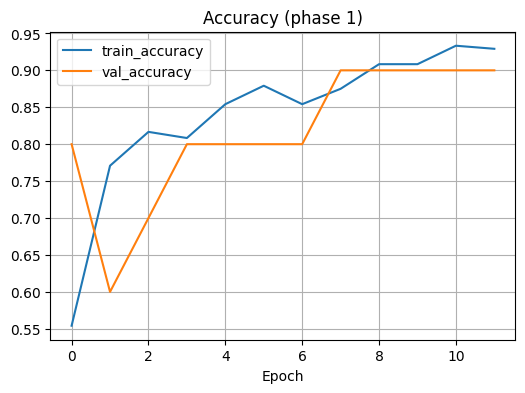

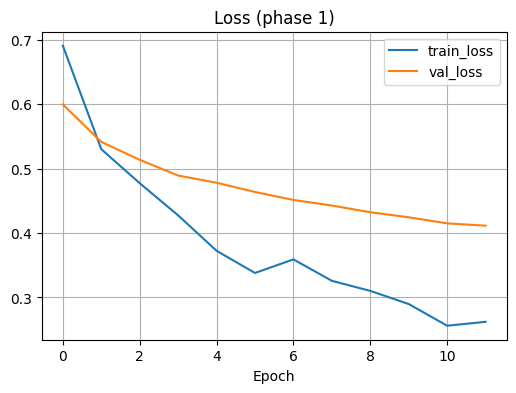

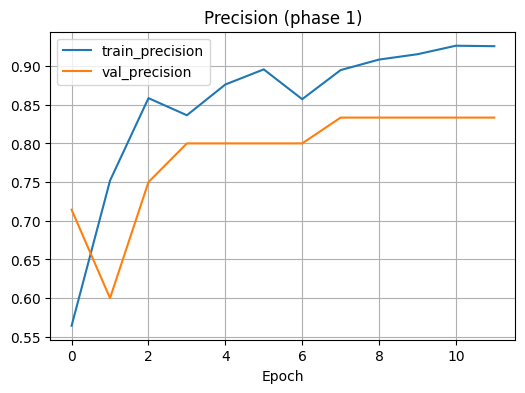

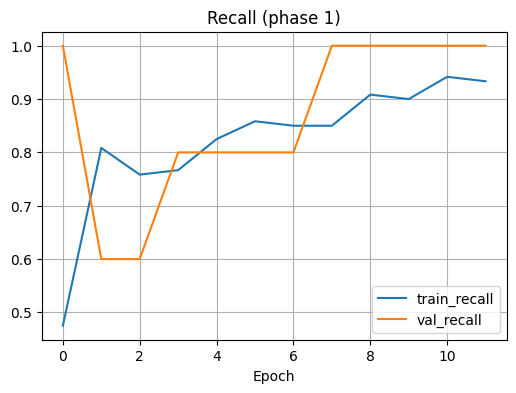

In [ ]:
def plot_metric(hist, key, title):
    plt.figure(figsize=(6,4))
    plt.plot(hist.history[key], label=f"train_{key}")
    plt.plot(hist.history["val_"+key], label=f"val_{key}")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_metric(history, "accuracy", "Accuracy (phase 1)")
plot_metric(history, "loss", "Loss (phase 1)")
plot_metric(history, "precision", "Precision (phase 1)")
plot_metric(history, "recall", "Recall (phase 1)")


In [ ]:
val_prob = model.predict(val_ds_b).ravel()
thresholds = np.linspace(0.05, 0.95, 19)

best_t, best_f1 = 0.5, -1
for t in thresholds:
    pred = (val_prob >= t).astype(int)
    f1 = f1_score(y_val, pred)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print("✅ Best threshold (val):", best_t, "Best F1 (val):", round(best_f1,3))

test_prob = model.predict(test_ds_b).ravel()
test_pred = (test_prob >= best_t).astype(int)

cm = confusion_matrix(y_test, test_pred)
print("✅ Confusion matrix (test):\n", cm)
print("\n✅ Report:\n", classification_report(y_test, test_pred, target_names=["OK(0)", "DEFECT(1)"]))


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
✅ Best threshold (val): 0.25 Best F1 (val): 0.909
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
✅ Confusion matrix (test):
 [[3 2]
 [0 5]]

✅ Report:
               precision    recall  f1-score   support

       OK(0)       1.00      0.60      0.75         5
   DEFECT(1)       0.71      1.00      0.83         5

    accuracy                           0.80        10
   macro avg       0.86      0.80      0.79        10
weighted avg       0.86      0.80      0.79        10



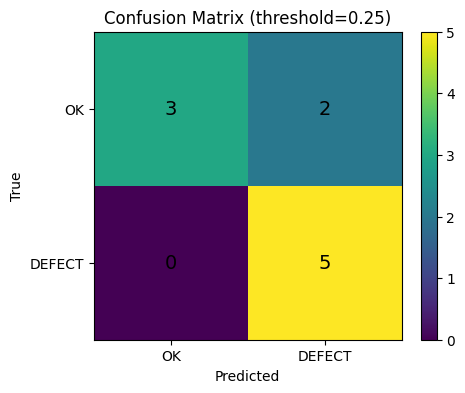

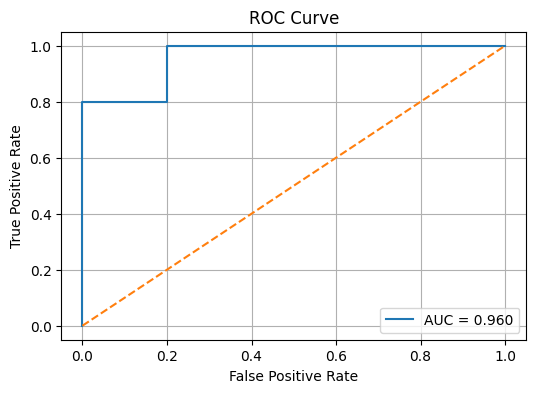

In [ ]:
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title(f"Confusion Matrix (threshold={best_t:.2f})")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0,1], ["OK", "DEFECT"])
plt.yticks([0,1], ["OK", "DEFECT"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", fontsize=14)
plt.colorbar()
plt.show()

fpr, tpr, _ = roc_curve(y_test, test_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

val_prob = model.predict(val_ds_b).ravel()

best_t = 0.5
best_correct = -1

for t in np.linspace(0.05, 0.95, 91):
    pred = (val_prob >= t).astype(int)
    cm = confusion_matrix(y_val, pred)
    correct = cm[0,0] + cm[1,1]  # diagonale

    if correct > best_correct:
        best_correct = correct
        best_t = t

print("✅ Best diagonal threshold:", best_t)
test_prob = model.predict(test_ds_b).ravel()
test_pred = (test_prob >= best_t).astype(int)

cm = confusion_matrix(y_test, test_pred)
print("Confusion matrix:\n", cm)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
✅ Best diagonal threshold: 0.24
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Confusion matrix:
 [[3 2]
 [0 5]]


In [ ]:
img_path = "/content/drive/MyDrive/6d15afa6-e2f3-49cc-b11f-4a71faf50dfb.jpg"
print("✅ Path:", img_path)


✅ Path: /content/drive/MyDrive/6d15afa6-e2f3-49cc-b11f-4a71faf50dfb.jpg


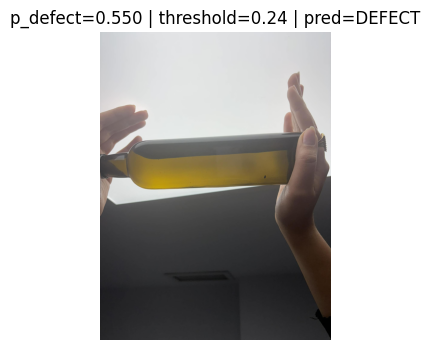

✅ p_defect: 0.5500075221061707 | pred: DEFECT


In [ ]:
IMG_SIZE = 224
t = best_t if "best_t" in globals() else 0.5  # seuil

def predict_one_cnn(model, img_path):
    bgr = cv2.imread(img_path)
    if bgr is None:
        raise ValueError("Image illisible: " + img_path)

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_res = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)/255.0

    p = float(model.predict(np.expand_dims(rgb_res,0), verbose=0)[0][0])
    pred = 1 if p >= t else 0

    plt.figure(figsize=(4,4))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(f"p_defect={p:.3f} | threshold={t:.2f} | pred={'DEFECT' if pred==1 else 'OK'}")
    plt.show()

    return p, pred

p, pred = predict_one_cnn(model, img_path)
print("✅ p_defect:", p, "| pred:", "DEFECT" if pred==1 else "OK")


✅ Path: /content/drive/MyDrive/image1.jfif


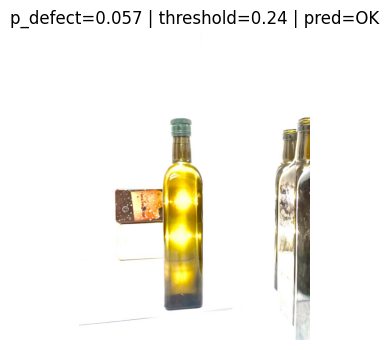

✅ p_defect: 0.05676767975091934 | pred: OK


In [ ]:
img_path = "/content/drive/MyDrive/image1.jfif"
print("✅ Path:", img_path)
IMG_SIZE = 224
t = best_t if "best_t" in globals() else 0.5  # seuil

def predict_one_cnn(model, img_path):
    bgr = cv2.imread(img_path)
    if bgr is None:
        raise ValueError("Image illisible: " + img_path)

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgb_res = cv2.resize(rgb, (IMG_SIZE, IMG_SIZE)).astype(np.float32)/255.0

    p = float(model.predict(np.expand_dims(rgb_res,0), verbose=0)[0][0])
    pred = 1 if p >= t else 0

    plt.figure(figsize=(4,4))
    plt.imshow(rgb)
    plt.axis("off")
    plt.title(f"p_defect={p:.3f} | threshold={t:.2f} | pred={'DEFECT' if pred==1 else 'OK'}")
    plt.show()

    return p, pred

p, pred = predict_one_cnn(model, img_path)
print("✅ p_defect:", p, "| pred:", "DEFECT" if pred==1 else "OK")


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/hack/hackathon/model_defect.keras"
model.save(SAVE_PATH)

print("✅ Modèle sauvegardé :", SAVE_PATH)


✅ Modèle sauvegardé : /content/drive/MyDrive/hack/hackathon/model_defect.keras


In [ ]:
SAVE_PATH = "/content/drive/MyDrive/hack/hackathon/model_defect.keras"
model.save(SAVE_PATH)
print("✅ Modèle sauvegardé:", SAVE_PATH)

✅ Modèle sauvegardé: /content/drive/MyDrive/hack/hackathon/model_defect.keras


In [ ]:
from google.colab import files
files.download(SAVE_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>